#### ※ 外れ値探索の流れ

<div style="
    background-color:#232627;
    width:70%;
    max-width:800px;
    margin-left:-35px;
    margin-right:auto;
    padding:0;
    color:#f2f2f2;
    font-family:monospace;
    font-size:14px;
">

<div style="
    background-color:#2b2f30;
    padding:9px 16px;
    text-align:center;
    font-size:18px;
    font-weight:bold;
">
［外れ値の探索］
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
│
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
┌──────────────┴──────────────┐
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
<span style="color:#ff6b35;">IQR</span> 方式　　　　　　　　　<span style="color:#ff6b35;">Z-score</span>
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
│　　　　　　　　　　　　　　│
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
中央値　　　　　　　　　　　 平均
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
│　　　　　　　　　　　　　　│
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
<span style="color:#ff6b35;">Q1 / Q3</span>　　　　　　　　　　 分散
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
│　　　　　　　　　　　　　　│
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
<span style="color:#ff6b35;">IQR</span>　　　　　　　　　　　 標準偏差
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
│　　　　　　　　　　　　　　│
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
上限値 / 下限値　　　　　　<span style="color:#ff6b35;">-3 &lt; Z-score &lt; +3</span>
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
│　　　　　　　　　　　　　　│
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
↓　　　　　　　　　　　　　　↓
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
<span style="color:#ff6b35;">200</span> 外れ値　　　　　　　　 <span style="color:#ff6b35;">200</span>？
</div>

<div style="background-color:#232627; padding:7px 16px; text-align:center;">
│　　　　　　　　　　　　　　│
</div>

<div style="background-color:#2b2f30; padding:7px 16px; text-align:center;">
ボックスプロット　　　　　　ヒストグラム
</div>

</div>

<br>

#### 収集したデータセット

<div style="background-color:#232627; padding:0;">

<div style="background-color:#2b2f30; padding:7px 16px;">
<span style="color:#ff6b35;">60, 62, 65, 67, 68, 70, 72, 75, 78, 95, 200</span>
</div>

</div>

<br>

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [13]:
# グラフで日本語が文字化けしないようにフォントを設定
plt.rcParams['font.family'] = 'Yu Gothic'

# グラフで「-」記号が文字化けするのを防止
plt.rcParams['axes.unicode_minus'] = False

## 1. データ準備

In [ ]:
scores = [60, 62, 65, 67, 68, 70, 72, 75, 78, 95, 200]

scores_np = np.array(scores)
scores_series = pd.Series(scores)

## 2. IQR方式

In [9]:
print("===== IQR方式 =====")

print()

# 中央値
median = scores_series.median()

# Q1、Q3
Q1 = scores_series.quantile(0.25)
Q3 = scores_series.quantile(0.75)

# IQR
IQR = Q3 - Q1

# 外れ値の判定基準
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 最小値、最大値
minimum = scores_series.min()
maximum = scores_series.max()

print("中央値:", median)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("下限値:", lower)
print("上限値:", upper)
print("最小値:", minimum)
print("最大値:", maximum)

print()

# 外れ値
outliers_iqr = scores_series[
    (scores_series < lower) | (scores_series > upper)
]

print("IQRの外れ値:")
print(outliers_iqr.values)

===== IQR方式 =====

中央値: 70.0
Q1: 66.0
Q3: 76.5
IQR: 10.5
下限値: 50.25
上限値: 92.25
最小値: 60
最大値: 200

IQRの外れ値:
[ 95 200]


## 3. ボックスプロット

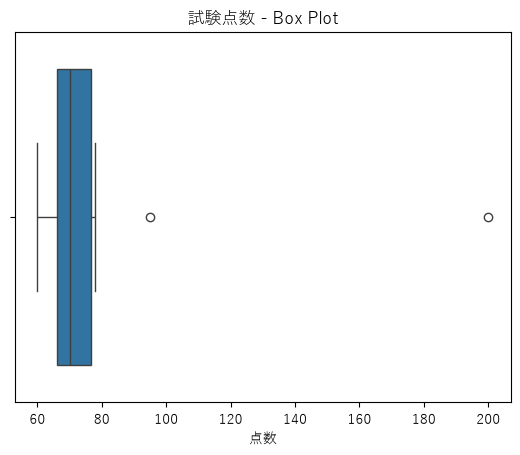

In [14]:
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.boxplot(x=scores_series, ax=axes1)

axes1.set_title("試験点数 - Box Plot")
axes1.set_xlabel("点数")

plt.show()

## 4. Z-score方式

In [ ]:
print("===== Z-score方式 =====")

print()

# 記述統計量は、同じデータを使用してもNumPy配列とPandas Seriesでは提供される機能やデフォルト値に違いがある。
# NumPyは主に母集団を基準とし、Pandasは標本を基準とする。

# 平均
mean = scores_np.mean()

# 分散
variance = scores_np.var()

# 標準偏差
std = scores_np.std()

print("平均:", round(mean, 2))
print("分散:", round(variance, 2))
print("標準偏差:", round(std, 2))

print()

# Z-scoreを計算
z_scores = (scores_np - mean) / std

print("Z-score:")
print(np.round(z_scores, 2))

===== Z-score方式 =====

平均: 82.91
分散: 1453.36
標準偏差: 38.12

Z-score:
[-0.6  -0.55 -0.47 -0.42 -0.39 -0.34 -0.29 -0.21 -0.13  0.32  3.07]


## 5. Z-scoreによる外れ値判定

In [17]:
outliers_z = scores_np[np.abs(z_scores) > 3]

print("Z-scoreの外れ値:")
print(outliers_z)

Z-scoreの外れ値:
[200]


## 6. ヒストグラム

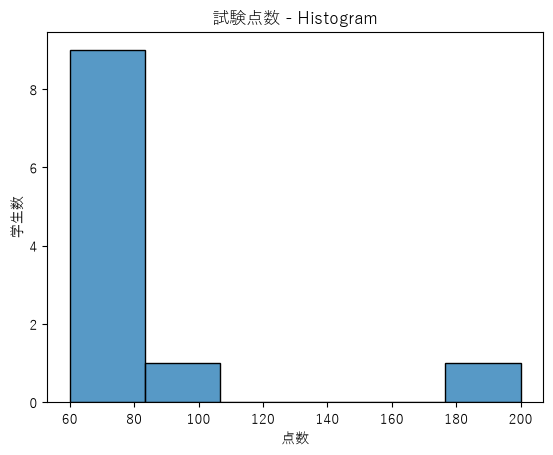

In [18]:
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores_series, bins=6, ax=axes1)

axes1.set_title("試験点数 - Histogram")
axes1.set_xlabel("点数")
axes1.set_ylabel("学生数")

plt.show()